<a href="https://colab.research.google.com/github/jahnavikrishnakancharla/-Lack-of-Access-to-Quality-Learning-Resources-/blob/main/Sleep_Disorder_Prediction_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [3]:
# Read dataset

df = pd.read_csv("/content/archive (6).zip")

# Show first 5 rows

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
# Dataset shape

print("Rows and Columns:")
print(df.shape)

# Column names

print("\nColumns:")
print(df.columns)

# Dataset info

df.info()

Rows and Columns:
(374, 13)

Columns:
Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   B

In [5]:
# Missing values

print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [6]:
df = df.drop("Person ID", axis=1)

df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [7]:
# Convert categorical columns

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,27,9,6.1,6,42,6,3,11,77,4200,2
1,1,28,1,6.2,6,60,8,0,9,75,10000,2
2,1,28,1,6.2,6,60,8,0,9,75,10000,2
3,1,28,6,5.9,4,30,8,2,22,85,3000,1
4,1,28,6,5.9,4,30,8,2,22,85,3000,1


In [24]:
df['Sleep Disorder']

,Sleep Disorder
0,2
1,2
2,2
3,1
4,1
...,...
369,1
370,1
371,1
372,1


In [10]:
X = df.drop("Sleep Disorder", axis=1)

y = df["Sleep Disorder"]

print(X.shape)
print(y.shape)

(374, 11)
(374,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(299, 11)
(75, 11)


In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Accuracy: 0.9066666666666666


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Accuracy: 0.88


In [14]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

Accuracy: 0.64


In [15]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_knn))

Accuracy: 0.8666666666666667


In [16]:
mlp = MLPClassifier(max_iter=1000)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_mlp))

Accuracy: 0.6266666666666667


In [17]:
results = {
    "Logistic Regression":
        accuracy_score(y_test, y_pred_lr),

    "Random Forest":
        accuracy_score(y_test, y_pred_rf),

    "SVM":
        accuracy_score(y_test, y_pred_svm),

    "KNN":
        accuracy_score(y_test, y_pred_knn),

    "MLP":
        accuracy_score(y_test, y_pred_mlp)
}

for model, score in results.items():
    print(model, ":", round(score*100,2), "%")

Logistic Regression : 90.67 %
Random Forest : 88.0 %
SVM : 64.0 %
KNN : 86.67 %
MLP : 62.67 %


In [18]:
best_model = max(results, key=results.get)

print("Best Model =", best_model)

Best Model = Logistic Regression


In [19]:
print("Precision:",
      precision_score(y_test,
                      y_pred_rf,
                      average='weighted'))

print("Recall:",
      recall_score(y_test,
                   y_pred_rf,
                   average='weighted'))

print("F1 Score:",
      f1_score(y_test,
               y_pred_rf,
               average='weighted'))

Precision: 0.8818596218596219
Recall: 0.88
F1 Score: 0.8785395537525356


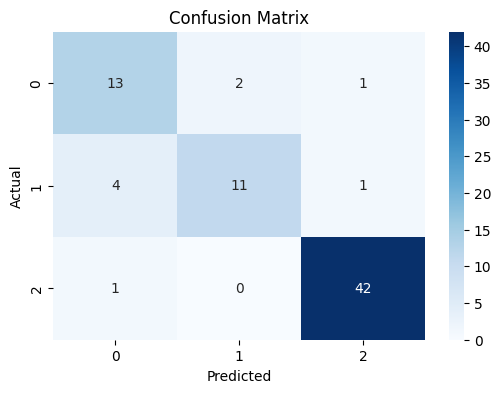

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
import joblib

joblib.dump(rf, "sleep_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [22]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 60.5 MB/s eta 0:00:00


In [25]:
loaded_model = joblib.load("sleep_model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


In [26]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd

model = joblib.load("sleep_model.pkl")

st.title("Sleep Disorder Prediction Agent")

age = st.number_input("Age", 18, 100, 25)
sleep_duration = st.number_input("Sleep Duration", 1.0, 12.0, 7.0)
stress_level = st.slider("Stress Level", 1, 10, 5)
heart_rate = st.number_input("Heart Rate", 40, 150, 70)
daily_steps = st.number_input("Daily Steps", 1000, 30000, 5000)

if st.button("Predict"):

    data = pd.DataFrame([[age,
                          sleep_duration,
                          stress_level,
                          heart_rate,
                          daily_steps]])

    prediction = model.predict(data)

    st.success(f"Predicted Sleep Disorder: {prediction[0]}")

Writing app.py


In [27]:
!streamlit run app.py &>/content/logs.txt &

In [34]:
from pyngrok import ngrok

ngrok.set_auth_token("2zBhmcJSiDjPhSYbtJmbK")

In [35]:
!streamlit run app.py &>/content/logs.txt &

In [37]:
from pyngrok import ngrok

# Kill any existing ngrok tunnels
ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-06-25T06:36:55+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: 2zBhmcJSiDjPhSYbtJmbK\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-25T06:36:55+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: 2zBhmcJSiDjPhSYbtJmbK\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: 2zBhmcJSiDjPhSYbtJmbK\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.